# Predicción de GRD — Hospital El Pino

**Objetivo:** Construir un predictor del Grupo Relacionado por el Diagnóstico (GRD) a partir de información clínica de los pacientes: diagnósticos, procedimientos, edad y sexo.

El dataset corresponde a registros oficiales de alta clínica del Hospital El Pino, con códigos estandarizados internacionalmente (CIE-10 para diagnósticos).

---

**Referencias clave:**
- He & Garcia (2009). *Learning from Imbalanced Data.* IEEE TKDE. — Submuestreo vs sobremuestreo en datasets de alta dimensionalidad.
- Elkan (2001). *The Foundations of Cost-Sensitive Learning.* IJCAI. — Class weights como alternativa a modificar los datos.
- Sokolova & Lapalme (2009). *A systematic analysis of performance measures.* IPM. — F1-Score Macro como métrica robusta para multiclase desbalanceado.
- Chen & Guestrin (2016). *XGBoost.* KDD. — Gradient Boosting para datos dispersos.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, mean_absolute_error, mean_squared_error
)

# Imbalanced-learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input, Dropout
from keras.models import Sequential
import keras_tuner

I0000 00:00:1778414293.413458    5547 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778414294.191167    5547 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778414296.222799    5547 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Análisis Exploratorio de Datos (EDA)

Se analiza la completitud, correctitud y outliers del dataset. Se incluyen estadísticas descriptivas y gráficos para visualizar características relevantes.

## Carga del dataset

In [2]:
# Configuración para visualizar todas las columnas
pd.set_option('display.max_info_columns', 500)
pd.set_option('display.max_columns', None)

df_elpino = pd.read_csv("dataset_elpino.csv", sep=';')

print(f"Dimensiones del dataset: {df_elpino.shape[0]} filas × {df_elpino.shape[1]} columnas")

df_elpino.head()

Dimensiones del dataset: 14561 filas × 68 columnas


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),Diag 11 Secundario (cod+des),Diag 12 Secundario (cod+des),Diag 13 Secundario (cod+des),Diag 14 Secundario (cod+des),Diag 15 Secundario (cod+des),Diag 16 Secundario (cod+des),Diag 17 Secundario (cod+des),Diag 18 Secundario (cod+des),Diag 19 Secundario (cod+des),Diag 20 Secundario (cod+des),Diag 21 Secundario (cod+des),Diag 22 Secundario (cod+des),Diag 23 Secundario (cod+des),Diag 24 Secundario (cod+des),Diag 25 Secundario (cod+des),Diag 26 Secundario (cod+des),Diag 27 Secundario (cod+des),Diag 28 Secundario (cod+des),Diag 29 Secundario (cod+des),Diag 30 Secundario (cod+des),Diag 31 Secundario (cod+des),Diag 32 Secundario (cod+des),Diag 33 Secundario (cod+des),Diag 34 Secundario (cod+des),Diag 35 Secundario (cod+des),Proced 01 Principal (cod+des),Proced 02 Secundario (cod+des),Proced 03 Secundario (cod+des),Proced 04 Secundario (cod+des),Proced 05 Secundario (cod+des),Proced 06 Secundario (cod+des),Proced 07 Secundario (cod+des),Proced 08 Secundario (cod+des),Proced 09 Secundario (cod+des),Proced 10 Secundario (cod+des),Proced 11 Secundario (cod+des),Proced 12 Secundario (cod+des),Proced 13 Secundario (cod+des),Proced 14 Secundario (cod+des),Proced 15 Secundario (cod+des),Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Proced 23 Secundario (cod+des),Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,"U07.1 - COVID-19, virus identificado",Y95 - Afección nosocomial,"N18.5 - Enfermedad renal crónica, estadio 5",E87.1 - Hiposmolaridad e hiponatremia,D64.9 - Anemia de tipo no especificado,"G82.2 - Paraplejía, no especificada","N31.9 - Disfunción neuromuscular de la vejiga,...",I10 - Hipertensión esencial (primaria),K70.4 - Insuficiencia hepática alcohólica,F19.2 - Trastornos mentales y del comportamien...,F10.2 - Trastornos mentales y del comportamien...,"E46 - Desnutrición proteicocalórica, no especi...","G40.9 - Epilepsia, tipo no especificado","L21.9 - Dermatitis seborreica, no especificada",Z93.5 - Cistostomía,Z93.3 - Colostomía,Z99.2 - Dependencia de diálisis renal,Z91.6 - Historia personal de otro trauma físico,-,-,-,-,-,-,-,"86.28 - DESBRIDAMIENTO HERIDA,INFECCION O QUEM...",34.91 - TORACOCENTESIS,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.41 - TOMOGRAFIA AXIAL COMPUTERIZADA TORAX,88.75 - ECOGRAFIA APARATO URINARIO,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,88.41 - ARTERIOGRAFIA ARTERIA CEREBRAL,87.44 - RADIOGRAFIA TORAX RUTINARIA,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,99.19 - INYECCION ANTICOAGULANTE,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,90.39 - EXAMEN MICROSCOPICO ORL.OTRO,99.84 - AISLAMIENTO,88.7

In [3]:
df_elpino.info()

<class 'pandas.DataFrame'>
RangeIndex: 14561 entries, 0 to 14560
Data columns (total 68 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Diag 01 Principal (cod+des)     14561 non-null  str  
 1   Diag 02 Secundario (cod+des)    14561 non-null  str  
 2   Diag 03 Secundario (cod+des)    14561 non-null  str  
 3   Diag 04 Secundario (cod+des)    14561 non-null  str  
 4   Diag 05 Secundario (cod+des)    14561 non-null  str  
 5   Diag 06 Secundario (cod+des)    14561 non-null  str  
 6   Diag 07 Secundario (cod+des)    14561 non-null  str  
 7   Diag 08 Secundario (cod+des)    14561 non-null  str  
 8   Diag 09 Secundario (cod+des)    14561 non-null  str  
 9   Diag 10 Secundario (cod+des)    14561 non-null  str  
 10  Diag 11 Secundario (cod+des)    14561 non-null  str  
 11  Diag 12 Secundario (cod+des)    14561 non-null  str  
 12  Diag 13 Secundario (cod+des)    14561 non-null  str  
 13  Diag 14 Secu

### Completitud

El dataset puede parecer que tiene datos faltantes representados con `-`, pero por la estructura clínica del sistema GRD esto solo indica que el paciente no tiene más diagnósticos o procedimientos secundarios — es un valor válido, no un dato faltante.

El siguiente gráfico muestra la cantidad de registros por columna.

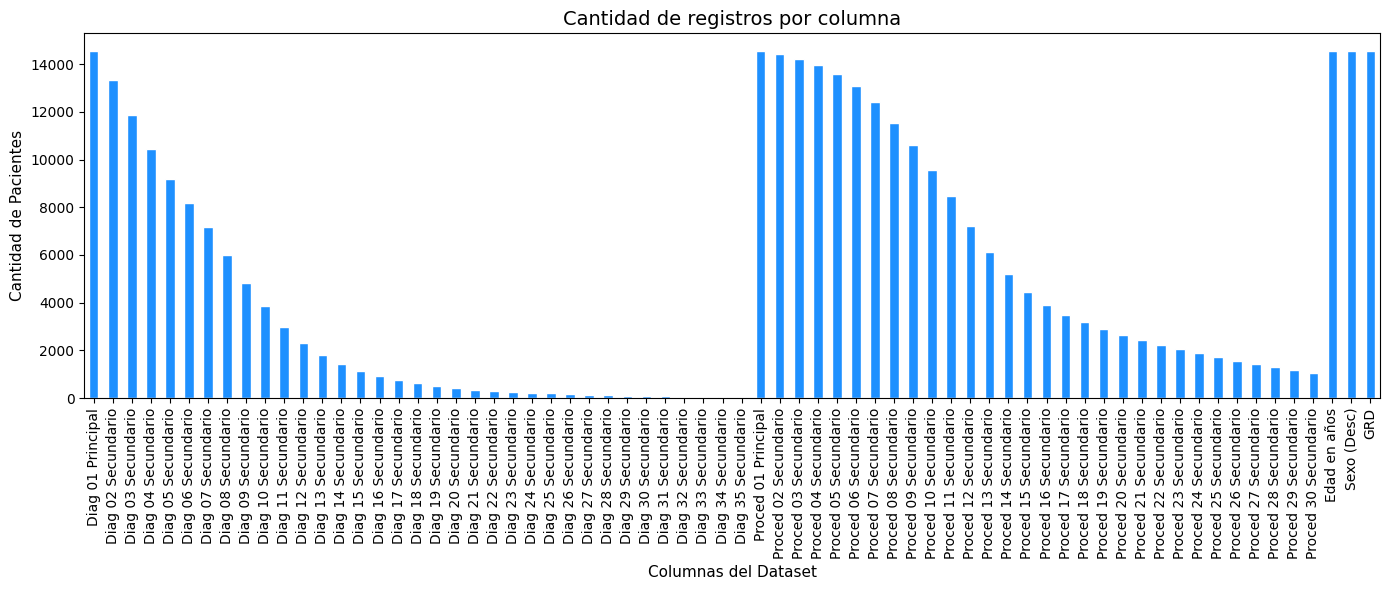


Total de pacientes en el dataset: 14561
Columnas con al menos 1 valor nulo:
Diag 02 Secundario (cod+des)       1209
Diag 03 Secundario (cod+des)       2687
Diag 04 Secundario (cod+des)       4127
Diag 05 Secundario (cod+des)       5371
Diag 06 Secundario (cod+des)       6394
                                  ...  
Proced 26 Secundario (cod+des)    12989
Proced 27 Secundario (cod+des)    13138
Proced 28 Secundario (cod+des)    13261
Proced 29 Secundario (cod+des)    13379
Proced 30 Secundario (cod+des)    13498
Length: 63, dtype: int64


In [4]:
# Reemplazar guiones por NaN para análisis de completitud
df_nulo = df_elpino.replace('-', np.nan).replace('', np.nan)

frecuencia_datos = df_nulo.count()
frecuencia_datos.index = frecuencia_datos.index.str.replace("(cod+des)", "", regex=False).str.strip()

plt.figure(figsize=(14, 6))
frecuencia_datos.plot.bar(color='dodgerblue', edgecolor='white')
plt.title('Cantidad de registros por columna', fontsize=14)
plt.xlabel('Columnas del Dataset', fontsize=11)
plt.ylabel('Cantidad de Pacientes', fontsize=11)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"\nTotal de pacientes en el dataset: {len(df_nulo)}")
print(f"Columnas con al menos 1 valor nulo:")
print(df_nulo.isnull().sum()[df_nulo.isnull().sum() > 0])

### Correctitud

La correctitud del dataset está respaldada por su origen: registros oficiales de alta clínica del Hospital El Pino. Los datos ingresados corresponden a códigos estandarizados internacionalmente (CIE-10 para diagnósticos), lo que minimiza errores tipográficos.

El modelo respeta la jerarquía clínica del sistema GRD dividiendo las variables en *Diagnósticos/Procedimientos Principales* y *Secundarios*, reconociendo que el orden causal de las enfermedades es fundamental para determinar la complejidad del paciente.

### Outliers — Edad

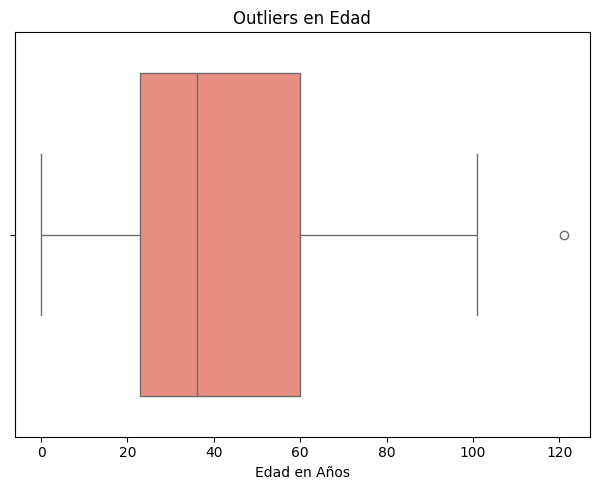

Top 10 Edades más altas registradas:
Edad en años
121     1
101     1
100     1
99      2
98      2
97      6
96      4
95      4
94     17
93     18
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(12, 5))

# Boxplot para detectar los outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df_elpino['Edad en años'].dropna(), color='salmon')
plt.title('Outliers en Edad')
plt.xlabel('Edad en Años')

plt.tight_layout()
plt.show()

# Para ver los números exactos de edades extremas:
edades_extremas = df_elpino['Edad en años'].value_counts().sort_index(ascending=False).head(10)
print("Top 10 Edades más altas registradas:")
print(edades_extremas)

### Estadísticas descriptivas y distribución de variables clave

In [6]:
# Preparar el dataframe limpio para el EDA
df_eda = df_elpino.copy()
df_eda.columns = df_eda.columns.str.replace("(cod+des)", "", regex=False).str.strip()
df_eda = df_eda.replace('-', np.nan).replace('', np.nan)

# Función para acortar nombres largos en los gráficos
def acortar_nombres(indice, max_len=50):
    return [str(n)[:max_len] + '...' if len(str(n)) > max_len else str(n) for n in indice]

# Calcular top 10 para cada variable
top_diag_prin = df_eda['Diag 01 Principal'].value_counts().head(10)
top_proc_prin = df_eda['Proced 01 Principal'].value_counts().head(10)

cols_diag_sec = [c for c in df_eda.columns if 'Diag' in c and 'Secundario' in c]
top_diag_sec = df_eda[cols_diag_sec].melt()['value'].dropna().value_counts().head(10)

cols_proc_sec = [c for c in df_eda.columns if 'Proced' in c and 'Secundario' in c]
top_proc_sec = df_eda[cols_proc_sec].melt()['value'].dropna().value_counts().head(10)

top_grd = df_eda['GRD'].value_counts().head(10)
sexo_counts = df_eda['Sexo (Desc)'].dropna().str.strip().value_counts()

print(f"Número de GRD únicos en el dataset: {df_eda['GRD'].nunique()}")
print(f"Número de diagnósticos principales únicos: {df_eda['Diag 01 Principal'].nunique()}")
print(f"Distribución por sexo:\n{sexo_counts.to_string()}")

Número de GRD únicos en el dataset: 526
Número de diagnósticos principales únicos: 1491
Distribución por sexo:
Sexo (Desc)
Mujer     9617
Hombre    4944


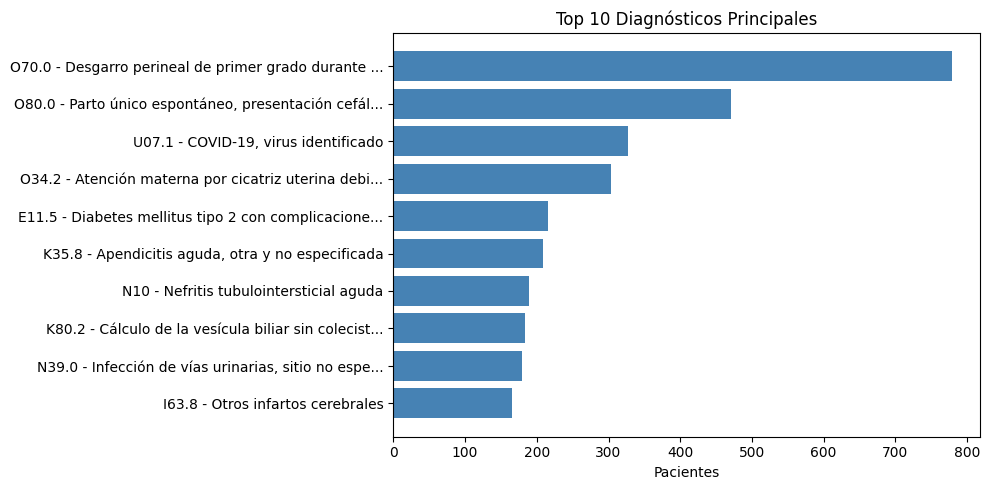

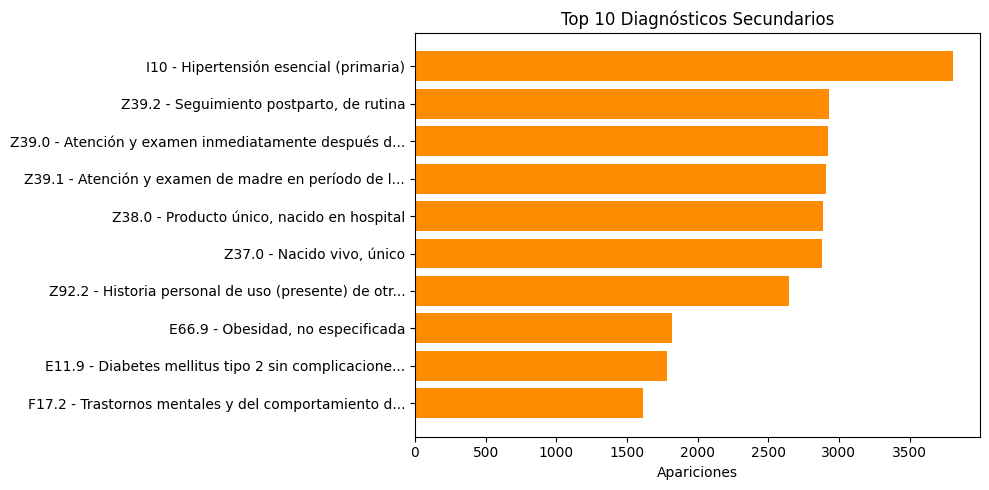

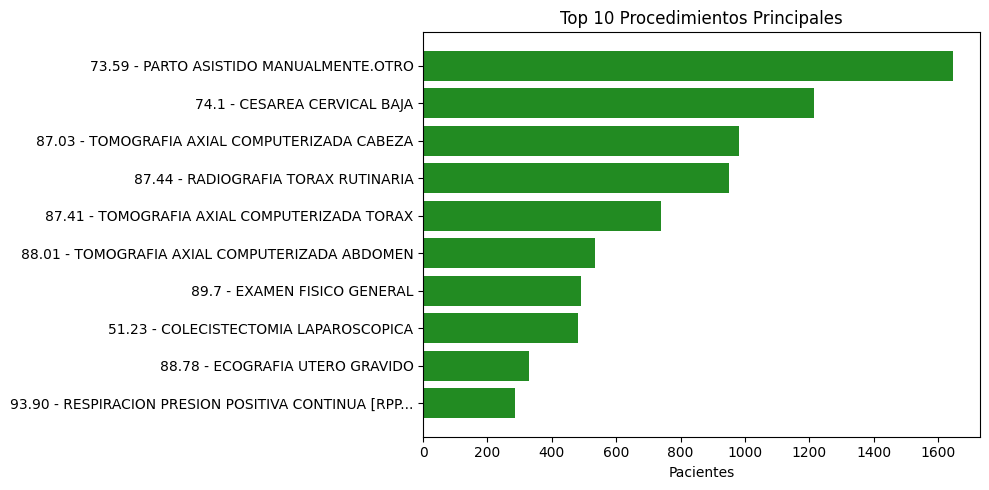

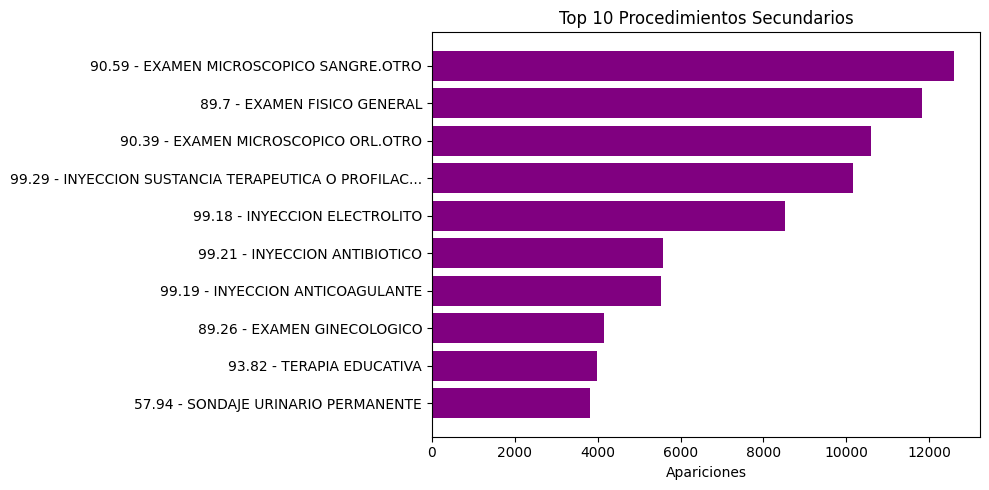

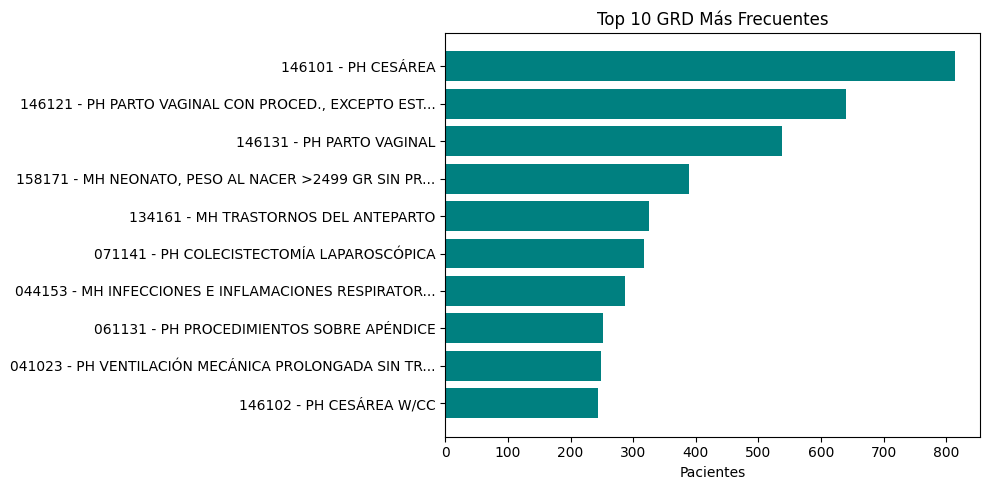

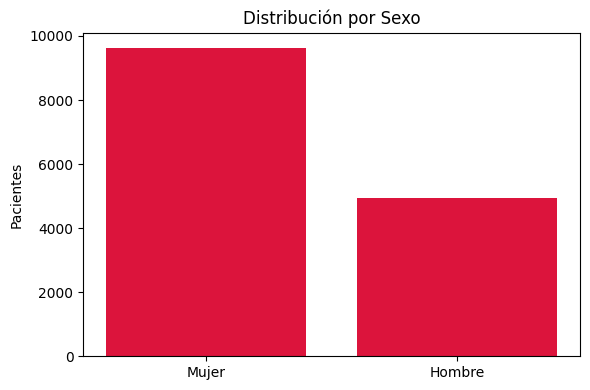

In [7]:
# Diagnósticos principales
plt.figure(figsize=(10, 5))
plt.barh(acortar_nombres(top_diag_prin.index), top_diag_prin.values, color='steelblue')
plt.gca().invert_yaxis() # Pone el más grande arriba
plt.title('Top 10 Diagnósticos Principales')
plt.xlabel('Pacientes')
plt.tight_layout()
plt.show()

# Diagnósticos secundarios 
plt.figure(figsize=(10, 5))
plt.barh(acortar_nombres(top_diag_sec.index), top_diag_sec.values, color='darkorange')
plt.gca().invert_yaxis()
plt.title('Top 10 Diagnósticos Secundarios')
plt.xlabel('Apariciones')
plt.tight_layout()
plt.show()

# Procedimientos principales
plt.figure(figsize=(10, 5))
plt.barh(acortar_nombres(top_proc_prin.index), top_proc_prin.values, color='forestgreen')
plt.gca().invert_yaxis()
plt.title('Top 10 Procedimientos Principales')
plt.xlabel('Pacientes')
plt.tight_layout()
plt.show()

# Procedimientos secundarios
plt.figure(figsize=(10, 5))
plt.barh(acortar_nombres(top_proc_sec.index), top_proc_sec.values, color='purple')
plt.gca().invert_yaxis()
plt.title('Top 10 Procedimientos Secundarios')
plt.xlabel('Apariciones')
plt.tight_layout()
plt.show()

# GRD más frecuentes
plt.figure(figsize=(10, 5))
plt.barh(acortar_nombres(top_grd.index), top_grd.values, color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 GRD Más Frecuentes')
plt.xlabel('Pacientes')
plt.tight_layout()
plt.show()

# Demografía 
plt.figure(figsize=(6, 4))
plt.bar(sexo_counts.index, sexo_counts.values, color='crimson')
plt.title('Distribución por Sexo')
plt.ylabel('Pacientes')
plt.tight_layout()
plt.show()

## Preparación de Datos para los Modelos

Se aplica una jerarquía clínica de 4 columnas: diagnóstico principal, procedimiento principal, diagnósticos secundarios agrupados y procedimientos secundarios agrupados. Las columnas principales usan CountVectorizer (presencia) y las secundarias TfidfVectorizer (penaliza repetición).

In [8]:
df = pd.read_csv("dataset_elpino.csv", sep=";")

# Extraer el código objetivo GRD 
df['GRD_Target'] = df['GRD'].astype(str).str.split(' - ').str[0].str.strip()

print(f"GRD únicos en el dataset original: {df['GRD_Target'].nunique()}")

GRD únicos en el dataset original: 526


In [9]:
# Funciones de limpieza de códigos clínicos
def limpiar_codigo(valor):
    valor_str = str(valor).strip()
    if valor_str and valor_str != '-' and valor_str != 'nan':
        return valor_str.split(' - ')[0].strip().replace(" ", "_")
    return ""

def unir_secundarios(fila):
    codigos = [limpiar_codigo(v) for v in fila if limpiar_codigo(v) != ""]
    return " ".join(codigos)

# Columnas principales (tratadas individualmente)
df['Diag_Principal'] = df['Diag 01 Principal (cod+des)'].apply(limpiar_codigo)
df['Proc_Principal'] = df['Proced 01 Principal (cod+des)'].apply(limpiar_codigo)

# Columnas secundarias (agrupadas en un solo string por paciente)
cols_diag_sec = [col for col in df.columns if 'Diag' in col and 'Secundario' in col]
cols_proc_sec = [col for col in df.columns if 'Proced' in col and 'Secundario' in col]

df['Diag_Secundarios'] = df[cols_diag_sec].apply(unir_secundarios, axis=1)
df['Proc_Secundarios'] = df[cols_proc_sec].apply(unir_secundarios, axis=1)

In [10]:
# Poda clínica: eliminar GRD con menos de 5 pacientes (no representativos)
MIN_PACIENTES = 5
conteos_grd = df['GRD_Target'].value_counts()
clases_validas = conteos_grd[conteos_grd >= MIN_PACIENTES].index
df_filtrado = df[df['GRD_Target'].isin(clases_validas)].copy()

print(f"GRD eliminados por tener menos de {MIN_PACIENTES} pacientes: {df['GRD_Target'].nunique() - len(clases_validas)}")
print(f"GRD válidos para modelar: {len(clases_validas)}")
print(f"Pacientes restantes: {len(df_filtrado)} (de {len(df)} originales)")

GRD eliminados por tener menos de 5 pacientes: 199
GRD válidos para modelar: 327
Pacientes restantes: 14135 (de 14561 originales)


In [11]:
# Definir features y target
X = df_filtrado[['Edad en años', 'Sexo (Desc)', 'Diag_Principal', 'Proc_Principal', 'Diag_Secundarios', 'Proc_Secundarios']]
y_strings = df_filtrado['GRD_Target']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_strings)
num_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [12]:
preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Edad en años']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['Sexo (Desc)']),
        ('diag_prin', CountVectorizer(token_pattern=r"(?u)\b[\w\.]+\b"), 'Diag_Principal'),
        ('proc_prin', CountVectorizer(token_pattern=r"(?u)\b[\w\.]+\b"), 'Proc_Principal'),
        ('diag_sec', TfidfVectorizer(token_pattern=r"(?u)\b[\w\.]+\b"), 'Diag_Secundarios'),
        ('proc_sec', TfidfVectorizer(token_pattern=r"(?u)\b[\w\.]+\b"), 'Proc_Secundarios'),
    ]
)

MAX_PACIENTES = 150
conteos_train = pd.Series(y_train).value_counts()
estrategia_recorte = {clase: min(conteo, MAX_PACIENTES) for clase, conteo in conteos_train.items()}
recortador = RandomUnderSampler(sampling_strategy=estrategia_recorte, random_state=42)

# Preprocesar UNA SOLA VEZ
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep  = preprocesador.transform(X_test)

# Recortar UNA SOLA VEZ
X_train_res, y_train_res = recortador.fit_resample(X_train_prep, y_train)

print("Preprocesador fitteado. Shape X_train_prep:", X_train_prep.shape)
print("Recorte aplicado.       Shape X_train_res: ", X_train_res.shape)

Preprocesador fitteado. Shape X_train_prep: (11308, 5318)
Recorte aplicado.       Shape X_train_res:  (9463, 5318)


## Modelos de Predicción

Se evalúan tres modelos:
1. Random Forest: Ensamble de árboles de decisión con bagging.
2. Regresión Logística: Modelo lineal base para clasificación multiclase.
3. Red Neuronal (Keras): Arquitectura optimizada con Keras Tuner.

### Random Forest & Regresión Logística

Ambos modelos se encapsulan en un pipeline imbalanced-learn que incluye el preprocesamiento y el submuestreo automáticamente.

In [13]:
# Definición de los modelos base
modelos_base = {
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "Regresión Logística": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    )
}

print("Modelos definidos:")
for nombre in modelos_base:
    print(f"  - {nombre}")

Modelos definidos:
  - Random Forest
  - Regresión Logística


In [14]:
resultados = {}  

for nombre, clasificador in modelos_base.items():
    inicio = time.time()

    # Sin recortador en el pipeline, ya se aplicó antes
    clasificador.fit(X_train_res, y_train_res)
    y_pred = clasificador.predict(X_test_prep)

    metricas = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision Macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1-Score Macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
    }
    resultados[nombre] = metricas

    fin = time.time()

    print(f"\n{nombre}")
    print("-" * 35)
    for metrica, valor in metricas.items():
        print(f"  {metrica:<18} {valor:.4f}")
    print("-" * 35)
    print(f"  Tiempo de entrenamiento: {fin - inicio:.1f} segundos")


Random Forest
-----------------------------------
  Accuracy           0.6134
  Precision Macro    0.4199
  Recall Macro       0.3869
  F1-Score Macro     0.3795
  MAE                11.7386
  MSE                1729.8773
-----------------------------------
  Tiempo de entrenamiento: 2.9 segundos

Regresión Logística
-----------------------------------
  Accuracy           0.6473
  Precision Macro    0.4383
  Recall Macro       0.4736
  F1-Score Macro     0.4375
  MAE                8.2105
  MSE                1205.5207
-----------------------------------
  Tiempo de entrenamiento: 9.2 segundos


### Red Neuronal (Keras con Keras Tuner)

Se utiliza RandomSearch de Keras Tuner para encontrar automáticamente la mejor arquitectura, la cual se basa en el número de capas, neuronas por capa, dropout y learning rate.

In [15]:
X_train_dense = X_train_res.toarray()
X_test_dense  = X_test_prep.toarray()
input_shape   = X_train_dense.shape[1]

print(f"Shape del conjunto de entrenamiento (denso): {X_train_dense.shape}")
print(f"Shape del conjunto de prueba (denso):         {X_test_dense.shape}")
print(f"Dimensiones de entrada (features): {input_shape}")
print(f"Clases de salida (GRD): {num_classes}")

Shape del conjunto de entrenamiento (denso): (9463, 5318)
Shape del conjunto de prueba (denso):         (2827, 5318)
Dimensiones de entrada (features): 5318
Clases de salida (GRD): 327


In [16]:
def build_model(hp):
 
    modelo = Sequential()
    modelo.add(Input(shape=(input_shape,)))

    # Entre 1 y 3 capas ocultas
    for i in range(hp.Choice("capas", [1, 2, 3])):
        modelo.add(Dense(
            units=hp.Choice(f"neuronas_capa_{i}", [64, 128, 256, 512]),
            activation="relu"
        ))
        modelo.add(Dropout(
            rate=hp.Choice(f"dropout_capa_{i}", [0.2, 0.3, 0.5])
        ))

    # Capa de salida multiclase
    modelo.add(Dense(num_classes, activation="softmax"))

    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=['accuracy']
    )
    return modelo

print("Función de construcción del modelo definida.")

Función de construcción del modelo definida.


In [17]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective=keras_tuner.Objective("val_accuracy", direction="max"),
    max_trials=10,          
    executions_per_trial=1,
    overwrite=True,
    directory="modelos_hospital",
    project_name="grd_optimizacion"
)

# Parada temprana si deja de mejorar tras 3 épocas, pasa a la siguiente arquitectura
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(
    X_train_dense, y_train_res,
    epochs=15,
    validation_data=(X_test_dense, y_test),
    callbacks=[stop_early],
    batch_size=64
)

print("\n Búsqueda completada.")

Trial 10 Complete [00h 00m 13s]
val_accuracy: 0.37884682416915894

Best val_accuracy So Far: 0.7962504625320435
Total elapsed time: 00h 05m 36s

 Búsqueda completada.


In [18]:
# Extraer el mejor modelo encontrado
mejor_modelo = tuner.get_best_models(num_models=1)[0]

print("Mejor modelo encontrado")
mejor_modelo.summary()

# Guardar el modelo 
mejor_modelo.save("mejor_modelo_grd.keras")
print("\nModelo guardado como 'mejor_modelo_grd.keras'")

Mejor modelo encontrado


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,723,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 327)            │       167,751 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,891,079 (11.03 MB)

 Trainable params: 2,891,079 (11.03 MB)

 Non-trainable params: 0 (0.00 B)


Modelo guardado como 'mejor_modelo_grd.keras'


In [19]:
print("Evaluando la red neuronal sobre el conjunto de prueba...")

y_pred_probs = mejor_modelo.predict(X_test_dense)
y_pred_nn = np.argmax(y_pred_probs, axis=1) 

metricas_nn = {
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision Macro': precision_score(y_test, y_pred_nn, average='macro', zero_division=0),
    'Recall Macro': recall_score(y_test, y_pred_nn, average='macro', zero_division=0),
    'F1-Score Macro': f1_score(y_test, y_pred_nn, average='macro', zero_division=0),
    'MAE': mean_absolute_error(y_test, y_pred_nn),
    'MSE': mean_squared_error(y_test, y_pred_nn),
}
resultados["Red Neuronal (Keras)"] = metricas_nn

print("\nRed Neuronal (Keras)")
print("-" * 35)
for metrica, valor in metricas_nn.items():
    print(f"  {metrica:<18} {valor:.4f}")
print("-" * 35)

Evaluando la red neuronal sobre el conjunto de prueba...
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Red Neuronal (Keras)
-----------------------------------
  Accuracy           0.7963
  Precision Macro    0.5790
  Recall Macro       0.5747
  F1-Score Macro     0.5594
  MAE                4.4843
  MSE                597.2731
-----------------------------------


## Comparativa Final de Modelos

In [20]:
df_resultados = pd.DataFrame(resultados).T

print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO DE MODELOS")
print("=" * 60)
print(df_resultados.round(4).to_string())
print("=" * 60)

mejor = df_resultados['F1-Score Macro'].idxmax()
print(f"\n Mejor modelo según F1-Score Macro: {mejor} ({df_resultados.loc[mejor, 'F1-Score Macro']:.4f})")


RESUMEN COMPARATIVO DE MODELOS
                      Accuracy  Precision Macro  Recall Macro  F1-Score Macro      MAE        MSE
Random Forest           0.6134           0.4199        0.3869          0.3795  11.7386  1729.8773
Regresión Logística     0.6473           0.4383        0.4736          0.4375   8.2105  1205.5207
Red Neuronal (Keras)    0.7963           0.5790        0.5747          0.5594   4.4843   597.2731

 Mejor modelo según F1-Score Macro: Red Neuronal (Keras) (0.5594)
